# Temporal patching + spatiotemporal composition

Mirror of `patching_intro`, walking through the temporal axes and the
`SpatioTemporalPatcher` composition. Shapes are annotated after every
operation so the data flow is explicit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from georeader.geotensor import GeoTensor

from geotoolz.patch import (
    RasterField,
    SpatialBoxcar,
    SpatialExplicit,
    SpatialOverlapAdd,
    SpatialPatcher,
    SpatialRectangular,
    SpatialRegularStride,
    SpatioTemporalPatcher,
    TemporalCausalBoxcar,
    TemporalExponentialDecay,
    TemporalFixedLookback,
    TemporalFold,
    TemporalForecast,
    TemporalLookbackHorizon,
    TemporalMean,
    TemporalPatcher,
    TemporalPeriodic,
    TemporalRegularStride,
    TemporalTaperedTukey,
)

## A temporal window gallery

`TemporalWindow.weights(geometry, length)` returns a 1-D weight array
whose length matches the temporal window's length. Recency, periodicity,
and spectral-leakage tapers all live here.

              CausalBoxcar: weights.shape: (16,)
     ExponentialDecay(τ=2): weights.shape: (16,)
     ExponentialDecay(τ=6): weights.shape: (16,)


       TaperedTukey(α=0.3): weights.shape: (16,)
       TaperedTukey(α=0.7): weights.shape: (16,)
        Periodic(period=8): weights.shape: (16,)


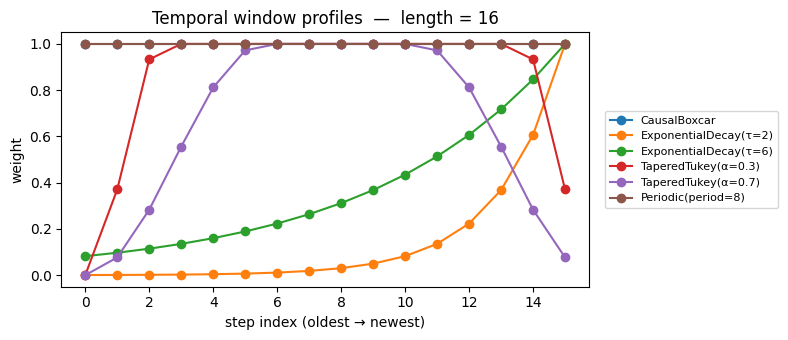

In [2]:
geom = TemporalFixedLookback(length=16)
length = 16

temporal_windows = {
    "CausalBoxcar": TemporalCausalBoxcar(),
    "ExponentialDecay(τ=2)": TemporalExponentialDecay(tau=2.0),
    "ExponentialDecay(τ=6)": TemporalExponentialDecay(tau=6.0),
    "TaperedTukey(α=0.3)": TemporalTaperedTukey(alpha=0.3),
    "TaperedTukey(α=0.7)": TemporalTaperedTukey(alpha=0.7),
    "Periodic(period=8)": TemporalPeriodic(period=8),
}

fig, ax = plt.subplots(figsize=(8, 3.5))
for name, w in temporal_windows.items():
    weights = w.weights(geom, length=length)
    print(f"{name:>26s}: weights.shape: {weights.shape}")
    ax.plot(weights, marker="o", label=name)
ax.set_title("Temporal window profiles  —  length = 16")
ax.set_xlabel("step index (oldest → newest)")
ax.set_ylabel("weight")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

## Lookback windows along a 1-D time series

series.shape: (100,)
len(patches): 9
patches[0].data.shape: (10,)      # (10,) — lookback length


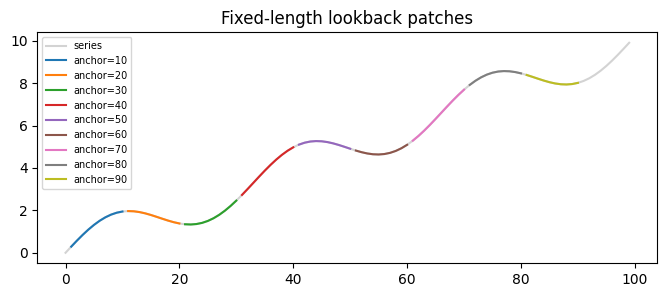

In [3]:
series = np.sin(np.linspace(0, 6 * np.pi, 100)) + 0.1 * np.arange(100)
print(f"series.shape: {series.shape}")  # (100,)

tp = TemporalPatcher(
    geometry=TemporalFixedLookback(length=10),
    sampler=TemporalRegularStride(step=10),
    window=TemporalCausalBoxcar(),
    aggregation=TemporalMean(),
)
patches = [p for p in tp.split(series) if p.data.shape[0] == 10]
print(f"len(patches): {len(patches)}")
print(f"patches[0].data.shape: {patches[0].data.shape}      # (10,) — lookback length")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(series, color="lightgray", label="series")
for p in patches:
    s = p.indices
    ax.plot(np.arange(s.start, s.stop), p.data, label=f"anchor={p.anchor}")
ax.legend(fontsize=7, loc="upper left")
ax.set_title("Fixed-length lookback patches")
plt.show()

## Exponential-decay weights applied to lookback

weights.shape: (10,), weights.sum(): 3.402


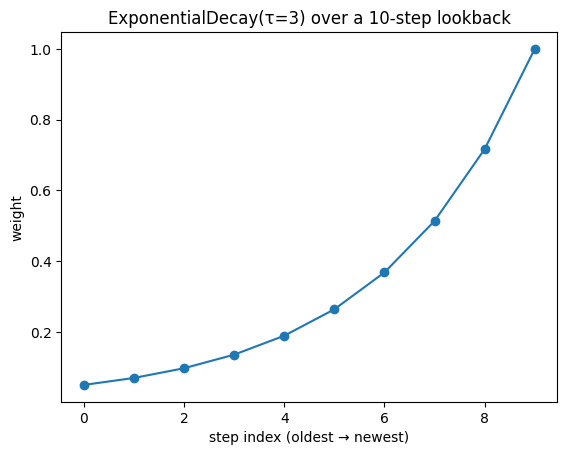

In [4]:
decay = TemporalExponentialDecay(tau=3.0)
weights = decay.weights(TemporalFixedLookback(length=10), length=10)
print(f"weights.shape: {weights.shape}, weights.sum(): {weights.sum():.3f}")

plt.plot(weights, marker="o")
plt.title("ExponentialDecay(τ=3) over a 10-step lookback")
plt.xlabel("step index (oldest → newest)")
plt.ylabel("weight")
plt.show()

## `TemporalFold` — stateful, RNN-like fold

Patches are folded sequentially with caller-supplied state.

In [5]:
running_sum = TemporalPatcher(
    geometry=TemporalFixedLookback(length=1),
    sampler=TemporalRegularStride(step=1),
    window=TemporalCausalBoxcar(),
    aggregation=TemporalFold(
        fold_fn=lambda s, p: (s or 0.0) + float(p.data[0]),
        initial_state=0.0,
    ),
)
total = running_sum.merge(list(running_sum.split(series)))
print(f"running sum at end: {total:.3f}")
print(f"np.sum(series)    : {series.sum():.3f}")

running sum at end: 495.000
np.sum(series)    : 495.000


## Forecasting with `TemporalLookbackHorizon`

Each patch carries lookback + horizon. The `TemporalForecast` aggregation
keeps only the horizon block per anchor.

In [6]:
forecast = TemporalPatcher(
    geometry=TemporalLookbackHorizon(lookback=5, horizon=3),
    sampler=TemporalRegularStride(step=8),
    window=TemporalCausalBoxcar(),
    aggregation=TemporalForecast(horizon=3),
)
patches_lh = list(forecast.split(series))
print(f"len(patches_lh): {len(patches_lh)}")
print(
    f"patches_lh[1].data.shape: {patches_lh[1].data.shape}   # (8,) = lookback+horizon"
)

# A trivial "model": copy the lookback's last value into the horizon.
predictions = []
for p in patches_lh:
    arr = np.asarray(p.data)
    if arr.shape[0] < 8:
        continue
    last = arr[4]  # end of the 5-step lookback
    pred = np.array([arr[0], arr[1], arr[2], arr[3], arr[4], last, last, last])
    pred_patch = type(p)(
        data=pred,
        anchor=p.anchor,
        indices=p.indices,
        weights=p.weights,
    )
    predictions.append(pred_patch)
aligned = forecast.merge(predictions)
print(f"len(aligned): {len(aligned)}")
for anchor, horizon_arr in aligned.items():
    print(f"  anchor={anchor}: horizon.shape={horizon_arr.shape}")

len(patches_lh): 13
patches_lh[1].data.shape: (8,)   # (8,) = lookback+horizon
len(aligned): 12
  anchor=8: horizon.shape=(3,)
  anchor=16: horizon.shape=(3,)
  anchor=24: horizon.shape=(3,)
  anchor=32: horizon.shape=(3,)
  anchor=40: horizon.shape=(3,)
  anchor=48: horizon.shape=(3,)
  anchor=56: horizon.shape=(3,)
  anchor=64: horizon.shape=(3,)
  anchor=72: horizon.shape=(3,)
  anchor=80: horizon.shape=(3,)
  anchor=88: horizon.shape=(3,)
  anchor=96: horizon.shape=(3,)


## `SpatioTemporalPatcher` — product coupling

Dense grid over space × time. A synthetic `(T=8, H=16, W=16)` raster —
`RasterField.select` reads the spatial window across all time steps, then
the temporal patcher chops along the leading axis.

In [7]:
arr3d = np.arange(8 * 16 * 16, dtype=np.float32).reshape(8, 16, 16)
print(f"arr3d.shape: {arr3d.shape}                # (T, H, W) = (8, 16, 16)")
field3d = RasterField(
    GeoTensor(values=arr3d, transform=rasterio.Affine.identity(), crs="EPSG:32630")
)

sp = SpatialPatcher(
    geometry=SpatialRectangular(size=(8, 8)),
    sampler=SpatialRegularStride(step=8),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)
tp = TemporalPatcher(
    geometry=TemporalFixedLookback(length=4),
    sampler=TemporalRegularStride(step=4),
    window=TemporalCausalBoxcar(),
    aggregation=TemporalMean(),
)
stp = SpatioTemporalPatcher(spatial=sp, temporal=tp, coupling="product")
patches3 = list(stp.split(field3d))
print(f"product coupling: {len(patches3)} patches")
print(f"  first.data.shape: {patches3[0].data.shape}     # (t_window, h, w)")
print(f"  first.(space, time): ({patches3[0].space}, {patches3[0].time})")

arr3d.shape: (8, 16, 16)                # (T, H, W) = (8, 16, 16)
product coupling: 8 patches
  first.data.shape: (1, 8, 8)     # (t_window, h, w)
  first.(space, time): ((0, 0), 0)


## Coupled coupling

Event-triggered patching: each anchor is an explicit `(space, time)` pair.

In [8]:
sp_explicit = SpatialPatcher(
    geometry=SpatialRectangular(size=(8, 8)),
    sampler=SpatialExplicit(anchors_=[((0, 0), 1), ((0, 8), 5), ((8, 0), 6)]),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)
stp_c = SpatioTemporalPatcher(
    spatial=sp_explicit,
    temporal=TemporalPatcher(
        geometry=TemporalFixedLookback(length=2),
        sampler=TemporalRegularStride(step=1),
        window=TemporalCausalBoxcar(),
        aggregation=TemporalMean(),
    ),
    coupling="coupled",
)
events = list(stp_c.split(field3d))
print("coupled events:")
for e in events:
    print(f"  space={e.space} time={e.time}  data.shape={e.data.shape}")

coupled events:
  space=(0, 0) time=1  data.shape=(2, 8, 8)
  space=(0, 8) time=5  data.shape=(2, 8, 8)
  space=(8, 0) time=6  data.shape=(2, 8, 8)
